In [1]:
# Purpose: Verify the Objective 1 notebook environment and available hardware

import sys
import platform
import torch
import numpy as np
import pandas as pd

print("=" * 70)
print("OBJECTIVE 1 — ENVIRONMENT VERIFICATION")
print("=" * 70)

print(f"Python version: {sys.version.split()[0]}")
print(f"Platform: {platform.system()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU count: {torch.cuda.device_count()}")

    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

print(f"Selected device: {device}")

OBJECTIVE 1 — ENVIRONMENT VERIFICATION
Python version: 3.12.13
Platform: Linux
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Selected device: cuda:0


In [2]:
# Purpose: Locate and inspect the attached HAM10000 dataset structure

from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")

print("=" * 70)
print("HAM10000 DATASET LOCATION CHECK")
print("=" * 70)

candidate_dirs = []

for path in KAGGLE_INPUT.rglob("*"):
    if path.is_dir() and "ham10000" in path.name.lower():
        candidate_dirs.append(path)

print("HAM10000-related directories:")

for path in candidate_dirs:
    print(path)

print("\nDataset files:")

for path in KAGGLE_INPUT.rglob("*"):
    if path.is_file() and (
        path.name in ["images.npy", "masks.npy", "metadata.csv"]
    ):
        if "ham" in str(path).lower():
            print(path)

print("\nDataset location check complete.")

HAM10000 DATASET LOCATION CHECK
HAM10000-related directories:
/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation

Dataset files:
/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation/validation/images.npy
/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation/validation/masks.npy
/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation/validation/metadata.csv
/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation/test/images.npy
/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation/test/masks.npy
/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation/test/metadata.csv
/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation/train/images.npy
/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation/train/masks.npy
/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation/train/metadata.csv

Dataset location check complete.


In [3]:
# Purpose: Verify HAM10000 split dimensions, mask structure, and metadata

from pathlib import Path
import numpy as np
import pandas as pd

HAM_ROOT = Path(
    "/kaggle/input/datasets/akansha1009/"
    "ham10000-preprocessed-segmentation"
)

print("=" * 70)
print("HAM10000 SPLIT AND MASK VERIFICATION")
print("=" * 70)

expected_splits = {
    "train": (6981, 224, 224, 3),
    "validation": (1532, 224, 224, 3),
    "test": (1502, 224, 224, 3)
}

for split, expected_shape in expected_splits.items():

    split_path = HAM_ROOT / split

    images = np.load(
        split_path / "images.npy",
        mmap_mode="r"
    )

    masks = np.load(
        split_path / "masks.npy",
        mmap_mode="r"
    )

    metadata = pd.read_csv(
        split_path / "metadata.csv"
    )

    print(f"\n{split.upper()}")
    print("-" * 50)

    print(f"Images shape:   {images.shape}")
    print(f"Expected shape: {expected_shape}")

    print(f"Masks shape:    {masks.shape}")
    print(f"Metadata shape: {metadata.shape}")

    print(f"Image dtype:    {images.dtype}")
    print(f"Mask dtype:     {masks.dtype}")

    print(
        f"Image range:    "
        f"{images.min():.4f} to {images.max():.4f}"
    )

    print(
        f"Mask range:     "
        f"{masks.min()} to {masks.max()}"
    )

    print(
        f"Image count OK: "
        f"{len(images) == expected_shape[0]}"
    )

    print(
        f"Mask count OK:  "
        f"{len(masks) == expected_shape[0]}"
    )

    print(
        f"Metadata count OK: "
        f"{len(metadata) == expected_shape[0]}"
    )

print("\n" + "=" * 70)
print("SPLIT VERIFICATION COMPLETE")
print("=" * 70)

HAM10000 SPLIT AND MASK VERIFICATION

TRAIN
--------------------------------------------------
Images shape:   (6981, 224, 224, 3)
Expected shape: (6981, 224, 224, 3)
Masks shape:    (6981, 224, 224)
Metadata shape: (6981, 2)
Image dtype:    float32
Mask dtype:     uint8
Image range:    0.0000 to 1.0000
Mask range:     0 to 1
Image count OK: True
Mask count OK:  True
Metadata count OK: True

VALIDATION
--------------------------------------------------
Images shape:   (1532, 224, 224, 3)
Expected shape: (1532, 224, 224, 3)
Masks shape:    (1532, 224, 224)
Metadata shape: (1532, 2)
Image dtype:    float32
Mask dtype:     uint8
Image range:    0.0000 to 1.0000
Mask range:     0 to 1
Image count OK: True
Mask count OK:  True
Metadata count OK: True

TEST
--------------------------------------------------
Images shape:   (1502, 224, 224, 3)
Expected shape: (1502, 224, 224, 3)
Masks shape:    (1502, 224, 224)
Metadata shape: (1502, 2)
Image dtype:    float32
Mask dtype:     uint8
Image rang

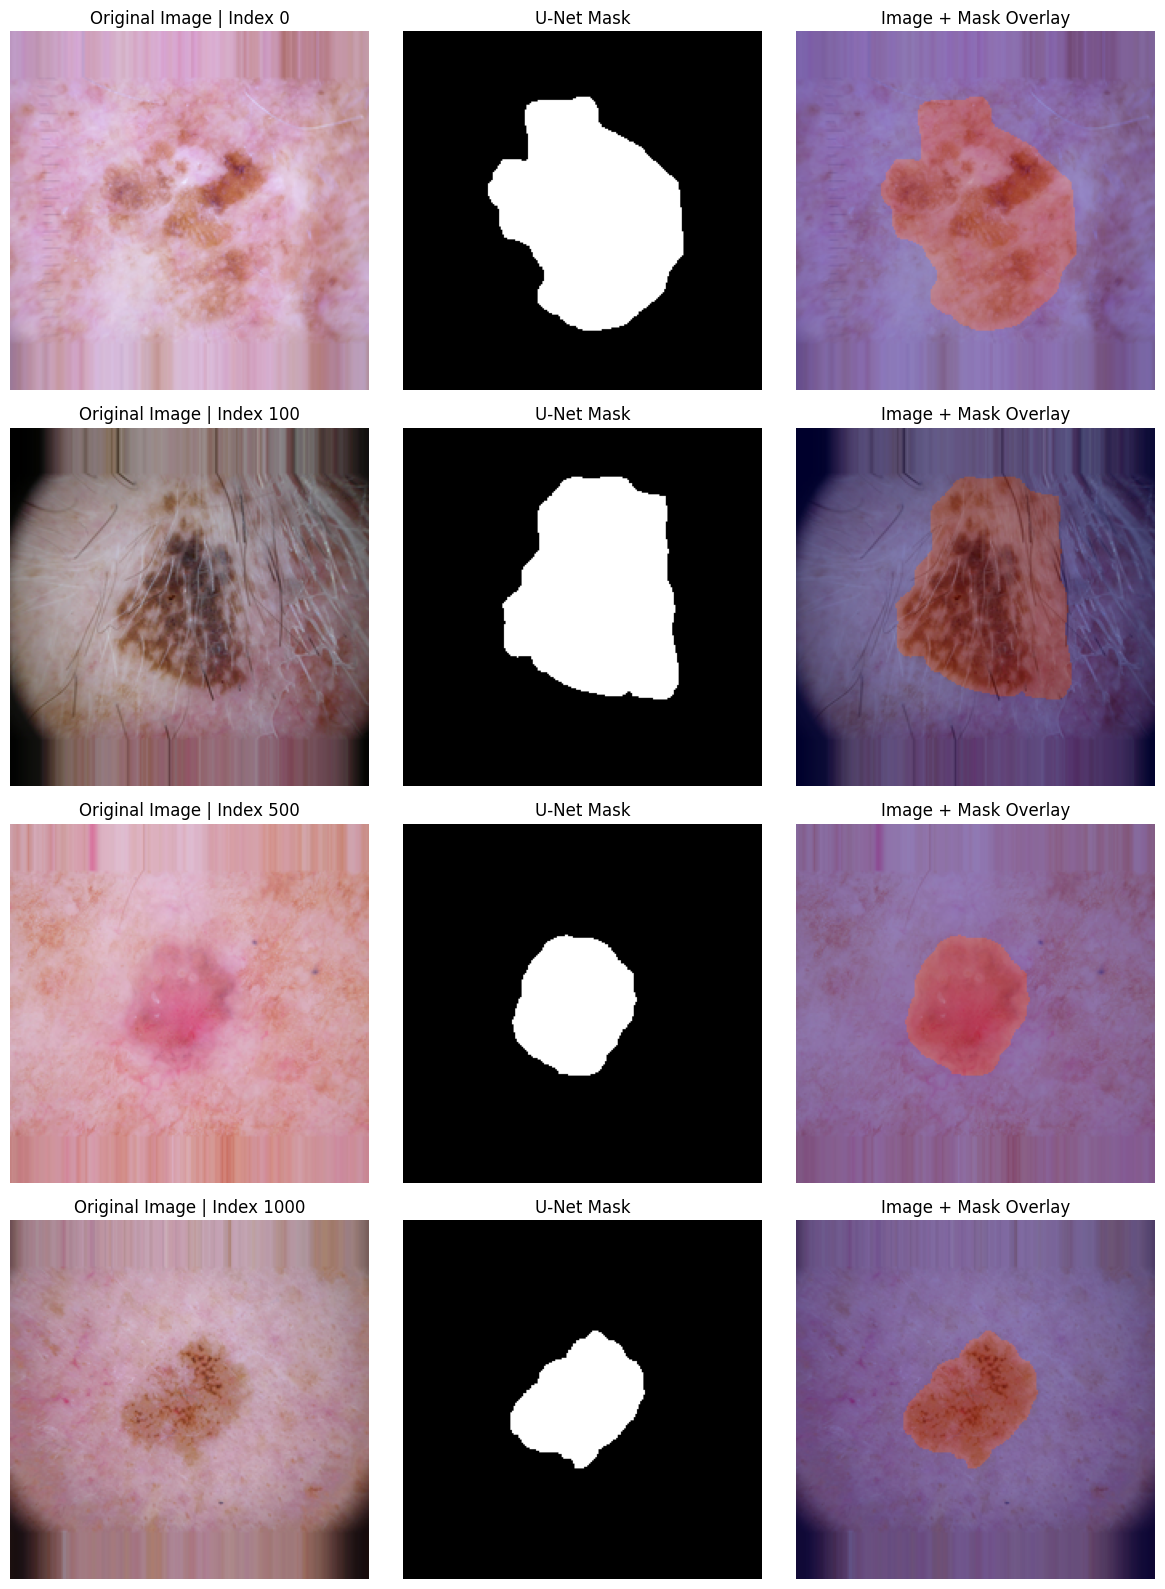

In [7]:
# Cell 4: Visually inspect verified HAM10000 images and U-Net masks

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

dataset_root = Path(
    "/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation"
)

train_path = dataset_root / "train"

train_images = np.load(train_path / "images.npy", mmap_mode="r")
train_masks = np.load(train_path / "masks.npy", mmap_mode="r")

sample_indices = [0, 100, 500, 1000]

fig, axes = plt.subplots(
    len(sample_indices),
    3,
    figsize=(12, 4 * len(sample_indices))
)

for row, idx in enumerate(sample_indices):
    image = np.asarray(train_images[idx])
    mask = np.asarray(train_masks[idx])

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Original Image | Index {idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("U-Net Mask")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(image)
    axes[row, 2].imshow(mask, alpha=0.35, cmap="jet")
    axes[row, 2].set_title("Image + Mask Overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Purpose: Verify the image-processing libraries required for Weighted Median and Watershed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy import ndimage
from skimage import filters, morphology, segmentation, measure, color

print("=" * 70)
print("OBJECTIVE 1 IMAGE PROCESSING LIBRARY CHECK")
print("=" * 70)

print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

print("\nRequired libraries:")
print("PIL: OK")
print("SciPy: OK")
print("scikit-image: OK")
print("Matplotlib: OK")

print("\nLibrary check complete.")

OBJECTIVE 1 IMAGE PROCESSING LIBRARY CHECK
NumPy: 2.0.2
Pandas: 2.3.3

Required libraries:
PIL: OK
SciPy: OK
scikit-image: OK
Matplotlib: OK

Library check complete.


In [9]:
# Purpose: Identify existing image arrays and datasets available in the Objective 1 notebook

print("=" * 70)
print("EXISTING IMAGE DATA CHECK")
print("=" * 70)

found = False

for name, value in list(globals().items()):
    if name.startswith("_"):
        continue

    if isinstance(value, np.ndarray):
        shape = value.shape

        if len(shape) >= 3:
            if (
                (len(shape) == 4 and shape[-1] in [1, 3, 4])
                or
                (len(shape) == 3 and shape[-1] in [1, 3, 4])
            ):
                print(f"Variable: {name}")
                print(f"  Shape: {shape}")
                print(f"  Dtype: {value.dtype}")
                print()

                found = True

if not found:
    print("No suitable image arrays found in the current variables.")

print("Image data check complete.")

EXISTING IMAGE DATA CHECK
Variable: images
  Shape: (1502, 224, 224, 3)
  Dtype: float32

Variable: train_images
  Shape: (6981, 224, 224, 3)
  Dtype: float32

Variable: image
  Shape: (224, 224, 3)
  Dtype: float32

Image data check complete.


WEIGHTED MEDIAN FILTER CHECK
Sample index: 100
Original shape: (224, 224, 3)
Filtered shape: (224, 224, 3)

Original range: 0.0667 to 0.8863
Filtered range: 0.0863 to 0.8784


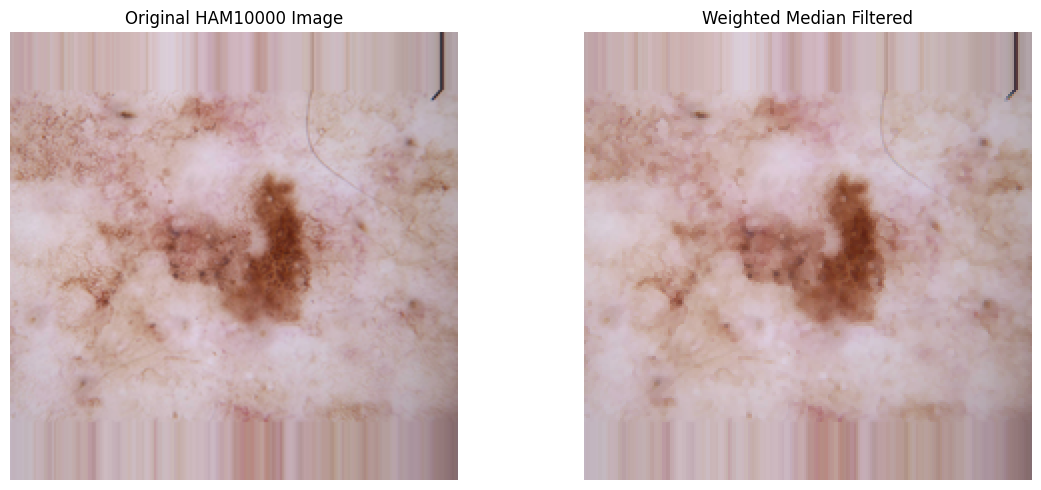

In [10]:
# Purpose: Apply and visually inspect a Weighted Median Filter on a HAM10000 test image

from scipy.ndimage import generic_filter

def weighted_median_filter(image, kernel_size=3):
    weights = np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ], dtype=np.float32)

    filtered = np.zeros_like(image)

    for channel in range(image.shape[2]):
        channel_image = image[:, :, channel]

        def weighted_median(values):
            values = np.asarray(values)
            repeated = np.repeat(values, weights.flatten().astype(int))
            return np.median(repeated)

        filtered[:, :, channel] = generic_filter(
            channel_image,
            weighted_median,
            size=kernel_size,
            mode="reflect"
        )

    return filtered.astype(np.float32)


sample_index = 100

original_image = np.clip(images[sample_index], 0.0, 1.0)

filtered_image = weighted_median_filter(
    original_image,
    kernel_size=3
)

print("=" * 70)
print("WEIGHTED MEDIAN FILTER CHECK")
print("=" * 70)

print(f"Sample index: {sample_index}")
print(f"Original shape: {original_image.shape}")
print(f"Filtered shape: {filtered_image.shape}")

print(f"\nOriginal range: {original_image.min():.4f} to {original_image.max():.4f}")
print(f"Filtered range: {filtered_image.min():.4f} to {filtered_image.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original_image)
axes[0].set_title("Original HAM10000 Image")
axes[0].axis("off")

axes[1].imshow(filtered_image)
axes[1].set_title("Weighted Median Filtered")
axes[1].axis("off")

plt.tight_layout()
plt.show()

WATERSHED SEGMENTATION
Input shape: (224, 224, 3)
Binary foreground pixels: 8367
Watershed regions: 16
Final lesion pixels: 3902


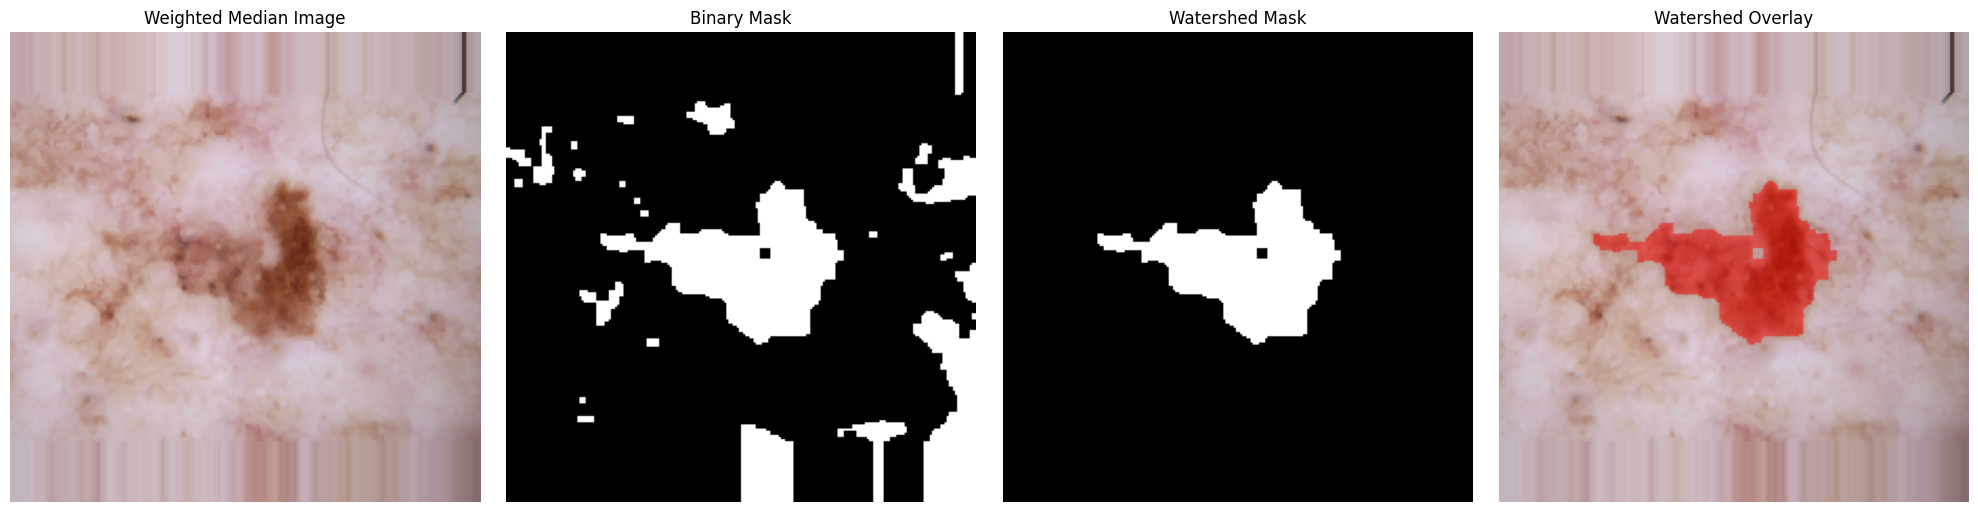


Watershed implementation complete.


In [11]:
# Purpose: Implement and visualize classical Watershed segmentation on a preprocessed HAM10000 lesion image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage as ndi

print("=" * 70)
print("WATERSHED SEGMENTATION")
print("=" * 70)

# Use the first available processed image from the existing notebook
if "filtered_image" in globals():
    watershed_input = filtered_image
elif "filtered_img" in globals():
    watershed_input = filtered_img
elif "weighted_median_image" in globals():
    watershed_input = weighted_median_image
else:
    raise NameError(
        "Could not find the weighted-median-filtered image variable. "
        "Please show me the cell where the filtered image is created."
    )

watershed_input = np.asarray(watershed_input)

# Convert to uint8 if the image is stored in the [0, 1] range
if watershed_input.dtype != np.uint8:
    watershed_uint8 = np.clip(watershed_input * 255, 0, 255).astype(np.uint8)
else:
    watershed_uint8 = watershed_input

# Convert RGB image to grayscale
gray = cv2.cvtColor(watershed_uint8, cv2.COLOR_RGB2GRAY)

# Otsu thresholding
_, binary = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Remove small noise and close small gaps
kernel = np.ones((3, 3), np.uint8)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

binary_bool = binary > 0

# Distance transform
distance = ndi.distance_transform_edt(binary_bool)

# Generate foreground markers from local maxima
coordinates = peak_local_max(
    distance,
    min_distance=15,
    labels=binary_bool
)

local_maxima = np.zeros_like(distance, dtype=bool)

if len(coordinates) > 0:
    local_maxima[
        tuple(coordinates.T)
    ] = True

markers, _ = ndi.label(local_maxima)

# Watershed segmentation
watershed_labels = watershed(
    -distance,
    markers,
    mask=binary_bool
)

watershed_mask = watershed_labels > 0

# Keep the largest connected watershed region
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    watershed_mask.astype(np.uint8),
    connectivity=8
)

if num_labels > 1:
    largest_region = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    final_mask = labels == largest_region
else:
    final_mask = watershed_mask

print(f"Input shape: {watershed_input.shape}")
print(f"Binary foreground pixels: {int(binary_bool.sum())}")
print(f"Watershed regions: {len(np.unique(watershed_labels)) - 1}")
print(f"Final lesion pixels: {int(final_mask.sum())}")

# Create overlay
overlay = watershed_uint8.copy()
overlay[final_mask] = (
    0.55 * overlay[final_mask] +
    0.45 * np.array([255, 0, 0])
).astype(np.uint8)

# Display results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(watershed_uint8)
axes[0].set_title("Weighted Median Image")
axes[0].axis("off")

axes[1].imshow(binary_bool, cmap="gray")
axes[1].set_title("Binary Mask")
axes[1].axis("off")

axes[2].imshow(final_mask, cmap="gray")
axes[2].set_title("Watershed Mask")
axes[2].axis("off")

axes[3].imshow(overlay)
axes[3].set_title("Watershed Overlay")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("\nWatershed implementation complete.")